# Bike Sharing Demand Prediction

## Import the libraries

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

## Loading the dataset

In [4]:
bikes = pd.read_csv('hour.csv')
bikes

,index,date,season,year,month,hour,holiday,weekday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,demand
0,1,01-01-2011,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,01-01-2011,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,01-01-2011,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,01-01-2011,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,01-01-2011,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,17375,31-12-2012,1,1,12,19,0,1,1,2,0.26,0.2576,0.60,0.1642,11,108,119
17375,17376,31-12-2012,1,1,12,20,0,1,1,2,0.26,0.2576,0.60,0.1642,8,81,89
17376,17377,31-12-2012,1,1,12,21,0,1,1,1,0.26,0.2576,0.60,0.1642,7,83,90
17377,17378,31-12-2012,1,1,12,22,0,1,1,1,0.26,0.2727,0.56,0.1343,13,48,61


## Prelim analysis and feature selection

### Drop unnecessary feature

In [5]:
bikes_prep = bikes.copy()
bikes_prep = bikes_prep.drop(['index', 'date', 'casual', 'registered'], axis=1)
bikes_prep.head()

,season,year,month,hour,holiday,weekday,workingday,weather,temp,atemp,humidity,windspeed,demand
0,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16
1,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40
2,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32
3,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13
4,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1


### Check for missing values

In [6]:
bikes_prep.isna().sum()

season        0
year          0
month         0
hour          0
holiday       0
weekday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
demand        0
dtype: int64

### Visualize the dataset (to check the distribution)

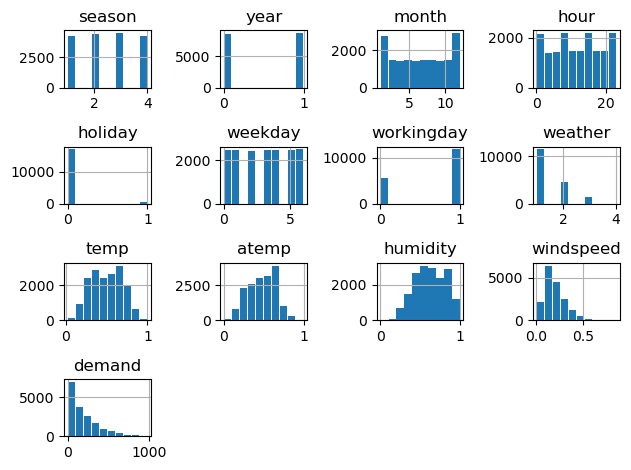

In [8]:
bikes_prep.hist(rwidth=0.9)
plt.tight_layout()

## Visualization of independent vs dependent
### Plot the continuous variables

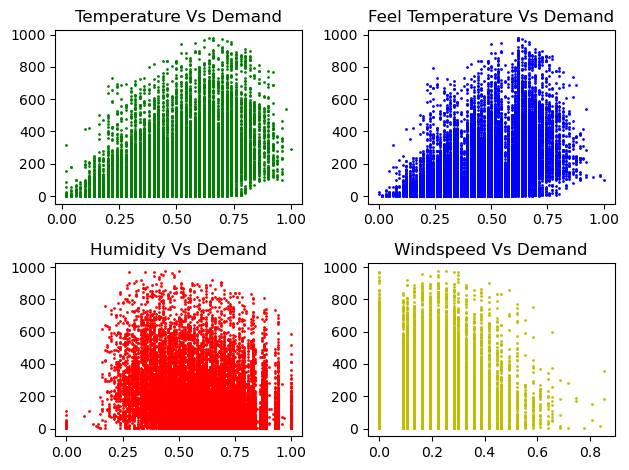

In [22]:
plt.subplot(2, 2, 1)
plt.scatter(bikes_prep['temp'], bikes_prep['demand'], s=1, c='g')
plt.title('Temperature Vs Demand')

plt.subplot(2, 2, 2)
plt.scatter(bikes_prep['atemp'], bikes_prep['demand'], s=1, c='b')
plt.title('Feel Temperature Vs Demand')

plt.subplot(2, 2, 3)
plt.scatter(bikes_prep['humidity'], bikes_prep['demand'], s=1, c='r')
plt.title('Humidity Vs Demand')

plt.subplot(2, 2, 4)
plt.scatter(bikes_prep['windspeed'], bikes_prep['demand'], s=1, c='y')
plt.title('Windspeed Vs Demand')

plt.tight_layout()

### Plot the categorical variables

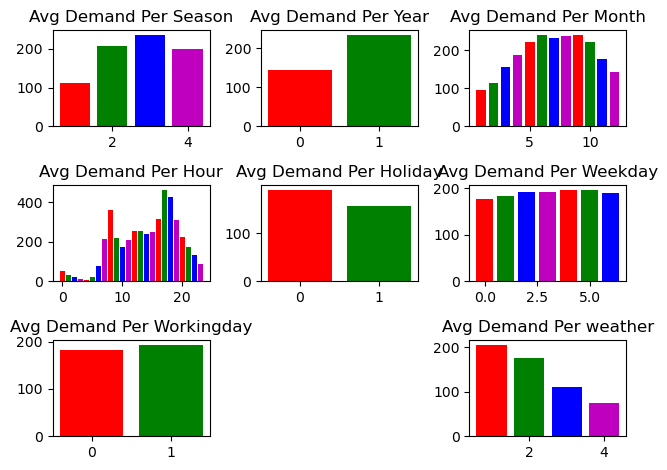

In [36]:
avg_demand_per_season = bikes_prep.groupby('season').mean()['demand']
plt.subplot(3, 3, 1)
plt.bar(avg_demand_per_season.index, avg_demand_per_season.values, color=['r', 'g', 'b', 'm'])
plt.title('Avg Demand Per Season')

avg_demand_per_year = bikes_prep.groupby('year').mean()['demand']
plt.subplot(3, 3, 2)
plt.bar(avg_demand_per_year.index, avg_demand_per_year.values, color=['r', 'g', 'b', 'm'])
plt.title('Avg Demand Per Year')

avg_demand_per_month = bikes_prep.groupby('month').mean()['demand']
plt.subplot(3, 3, 3)
plt.bar(avg_demand_per_month.index, avg_demand_per_month.values, color=['r', 'g', 'b', 'm'])
plt.title('Avg Demand Per Month')

avg_demand_per_hour = bikes_prep.groupby('hour').mean()['demand']
plt.subplot(3, 3, 4)
plt.bar(avg_demand_per_hour.index, avg_demand_per_hour.values, color=['r', 'g', 'b', 'm'])
plt.title('Avg Demand Per Hour')

avg_demand_per_holiday = bikes_prep.groupby('holiday').mean()['demand']
plt.subplot(3, 3, 5)
plt.bar(avg_demand_per_holiday.index, avg_demand_per_holiday.values, color=['r', 'g', 'b', 'm'])
plt.title('Avg Demand Per Holiday')

avg_demand_per_weekday = bikes_prep.groupby('weekday').mean()['demand']
plt.subplot(3, 3, 6)
plt.bar(avg_demand_per_weekday.index, avg_demand_per_weekday.values, color=['r', 'g', 'b', 'm'])
plt.title('Avg Demand Per Weekday')

avg_demand_per_workingday = bikes_prep.groupby('workingday').mean()['demand']
plt.subplot(3, 3, 7)
plt.bar(avg_demand_per_workingday.index, avg_demand_per_workingday.values, color=['r', 'g', 'b', 'm'])
plt.title('Avg Demand Per Workingday')

avg_demand_per_weather = bikes_prep.groupby('weather').mean()['demand']
plt.subplot(3, 3, 9)
plt.bar(avg_demand_per_weather.index, avg_demand_per_weather.values, color=['r', 'g', 'b', 'm'])
plt.title('Avg Demand Per weather')

plt.tight_layout()

Text(0.5, 1.0, 'Avg Demand Per Hour')

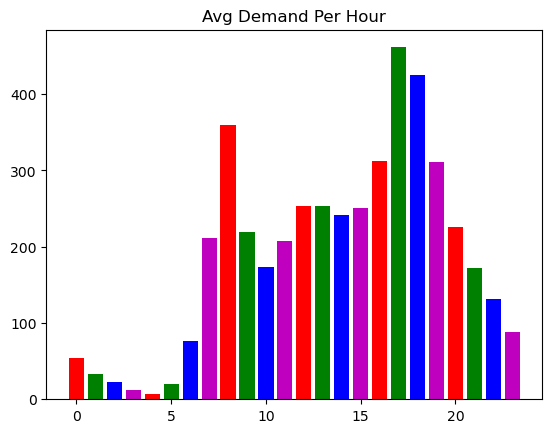

In [38]:
avg_demand_per_hour = bikes_prep.groupby('hour').mean()['demand']
plt.bar(avg_demand_per_hour.index, avg_demand_per_hour.values, color=['r', 'g', 'b', 'm'])
plt.title('Avg Demand Per Hour')